# -----------------------------------------------------------------
- Anderson Jawarlan Vargas Ruiz
- Ciencia de DAtos 5to Semestre
# -----------------------------------------------------------------

## Librerias

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

## Datos

### Transformación de datos
1. Establecer campos traducidos
2. Obtenemos datos especificos para el modelo
3. Mostramos Datos iniciales

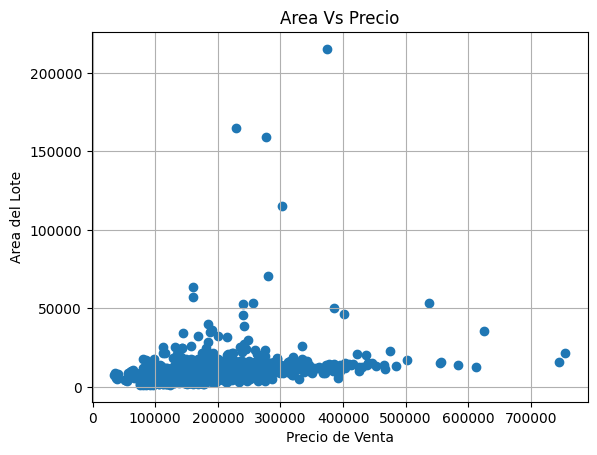

In [ ]:
Trad_Campos = {
    'MSSubClass':'Subclase MS',
    'MSZoning':'Zonificación MS',
    'LotFrontage':'Fachada del lote',
    'LotArea':'Área del lote',
    'Street':'Calle',
    'Alley':'Callejón',
    'LotShape':'Forma del lote',
    'LandContour':'Contorno del terreno',
    'Utilities':'Servicios públicos',
    'LotConfig':'Configuración del lote',
    'LandSlope':'Ladera terrestre',
    'Neighborhood':'Barrio',
    'Condition1':'Condición 1',
    'Condition2':'Condición 2',
    'BldgType':'Tipo Edificio',
    'HouseStyle':'Estilo de la Casa',
    'OverallQual':'Clasificación general',
    'OverallCond':'Dirección general',
    'YearBuilt':'Año de construcción',
    'YearRemodAdd':'Añadir remodificación de año',
    'RoofStyle':'Estilo de tejado',
    'RoofMatl':'Tejado de tejado',
    'Exterior1st':'Exterior 1º',
    'Exterior2nd':'Segundo exterior',
    'MasVnrType':'Tipo Mas Vnr',
    'MasVnrArea':'Área de Mas Vnr',
    'ExterQual':'Exter Qual',
    'ExterCond':'Exter Cond',
    'Foundation':'Fundación',
    'BsmtQual':'Bsmt Qual',
    'BsmtCond':'Residencia de Bsmt',
    'BsmtExposure':'Exposición al Bsmt',
    'BsmtFinType1':'Tipo de aleta Bsmt Tipo1',
    'BsmtFinSF1':'Bsmt Fin SF1',
    'BsmtFinType2':'Tipo de aleta Bsmt 2',
    'BsmtFinSF2':'Bsmt Fin SF2',
    'BsmtUnfSF':'Bsmt Unf SF',
    'TotalBsmtSF':'Total Bsmt SF',
    'Heating':'Calefacción',
    'HeatingQC':'Control de calidad de calefacción',
    'CentralAir':'Aire Acondicionado Central',
    'Electrical':'Eléctrico',
    '1stFlrSF':'1ª Clase de Fantasía',
    '2ndFlrSF':'2ª FlrSF',
    'LowQualFinSF':'Baja cualificación Fin SF',
    'GrLivArea':'Área de GrLiv',
    'BsmtFullBath':'Bsmt Baño Completo',
    'BsmtHalfBath':'Bsmt Medio Baño',
    'FullBath':'Baño Completo',
    'HalfBath':'Medio baño',
    'BedroomAbvGr':'Dormitorio ABV Gr',
    'KitchenAbvGr':'Cocina Álbuna Gr',
    'KitchenQual':'Calificación de cocina',
    'TotRmsAbvGrd':'Alto Álcool Gruñón',
    'Functional':'Funcional',
    'Fireplaces':'Chimeneas',
    'FireplaceQu':'Fireplace Qu',
    'GarageType':'Tipo de garaje',
    'GarageYrBlt':'Garage Yr Blt',
    'GarageFinish':'Acabado en garaje',
    'GarageCars':'Coches de garaje',
    'GarageArea':'Zona de garajes',
    'GarageQual':'Clasificación de garaje',
    'GarageCond':'Configuración del garaje',
    'PavedDrive':'Camino pavimentado',
    'WoodDeckSF':'Cubierta de madera SF',
    'OpenPorchSF':'SF con porche abierto',
    'EnclosedPorch':'Pórtico cerrado',
    '3SsnPorch':'3Ssn Porch',
    'ScreenPorch':'Pórtico con pantalla',
    'PoolArea':'Zona de la piscina',
    'PoolQC':'Control de calidad en piscina',
    'Fence':'Valla',
    'MiscFeature':'Características diversas',
    'MiscVal':'Misceláneos Val',
    'MoSold':'Mo Sold',
    'YrSold':'Año vendido',
    'SaleType':'Tipo de venta',
    'SaleCondition':'Condición de venta',
    'SalePrice':'Precio de venta'
}

Datos = pd.read_csv("train.csv").rename(columns=Trad_Campos)

Campos = ["Año vendido","Área del lote","Precio de venta"]
Area_Precio = Datos[Campos]

plt.scatter(Area_Precio.iloc[:,[-1]],Area_Precio.iloc[:,[1]])
plt.title("Area Vs Precio")
plt.ylabel("Area del Lote")
plt.xlabel("Precio de Venta")
plt.grid()

## Entrenamiento

### Modelo de prediccion
1. Se establecen datos para el entrenamiento del modelo
2. Se entrena el modelo con los datos para realizar la regresión lineal
3. obtenemos los parametros de acuerdo a lo estudiado en el modelo.
4. Imprimimos los datos importantes para tener los datos proyectados

In [3]:
x = np.array(Area_Precio.iloc[:,[-1]]).reshape(-1,1)
y = np.array(Area_Precio.iloc[:,[1]])

modelo = LinearRegression()
modelo.fit(x,y)

b = modelo.intercept_[0]
m = modelo.coef_[0]

y_pred = modelo.predict(x)

r2 = r2_score(y,y_pred)
recm = (mean_squared_error(y,y_pred))**(1/2)

print("r2:",r2) #
print("RECM:",recm) #Error cuadratico medio

print(f"Pendiente: {m}")
print(f"Punto de corte: {b}")

print(f"Y = {m} X + ({b})")

r2: 0.0696133153821119
RECM: 9624.286535681085
Pendiente: [0.03314964]
Punto de corte: 4519.355469004602
Y = [0.03314964] X + (4519.355469004602)


## Predecir Datos

## Establecemos datos para predecir en nuestro modelo.
1. Creamos un DF que nos permita recolectar unformación para predecir y obtener el dato predecido
2. Establecemos parametros para la graficación

In [ ]:
# Datos para uscar
Datos_Pred = {"Área del lote":[
    300000,
    400000,
    500000,
    700000,
    800000]
}

# Pandas con datos encontrados de acuerdo al modelo.
Datos_Pred_Pd = pd.DataFrame(Datos_Pred)
Datos_Pred_Pd["Precio de venta"] = (m*(Datos_Pred_Pd["Área del lote"]) + b)
Datos_Pred_Pd

#Datos para graficar
x_P = np.array(Datos_Pred_Pd.iloc[:,[-1]])
y_P = np.array(Datos_Pred_Pd.iloc[:,[0]])

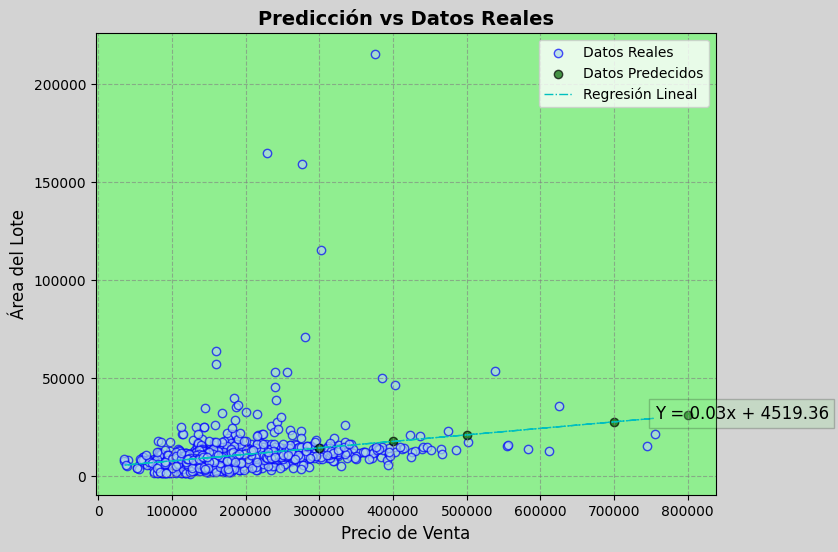

,Área del lote,Precio de venta
0,300000,14464.247637
1,400000,17779.211692
2,500000,21094.175748
3,700000,27724.103860
4,800000,31039.067916


In [61]:
# Crear figura y ejes
fig, ax = plt.subplots(figsize=(8,6))

# Gráficos de dispersión (Datos Reales Vs Datos Predecidos)
ax.scatter(x, y, label="Datos Reales", color="lightblue", alpha=0.7, edgecolor="blue")
ax.scatter(y_P, x_P, label="Datos Predecidos", color="darkgreen", alpha=0.7, edgecolor="k")

# Línea de regresión
ax.plot(x, y_pred, "-.c", label="Regresión Lineal", linewidth=1)
ax.text(x.max(), m[0]*x.max() + b, f"Y = {m[0]:.2f}x + {b:.2f}",fontsize=12, color="k",
        bbox=dict(facecolor="lightgreen", alpha=0.2))

# Títulos y etiquetas
ax.set_title("Predicción vs Datos Reales", fontsize=14, fontweight="bold")
ax.set_xlabel("Precio de Venta", fontsize=12)
ax.set_ylabel("Área del Lote", fontsize=12)

# Cuadrícula y leyenda
ax.grid(True, color="gray", linestyle="--", alpha=0.6)
ax.legend(loc="best", fontsize=10)

# Fondo personalizado
ax.set_facecolor("lightgreen")   # fondo del área de la gráfica
fig.patch.set_facecolor("lightgray")  # fondo de toda la figura

# Mostramos los Datos
plt.show()
Datos_Pred_Pd